In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

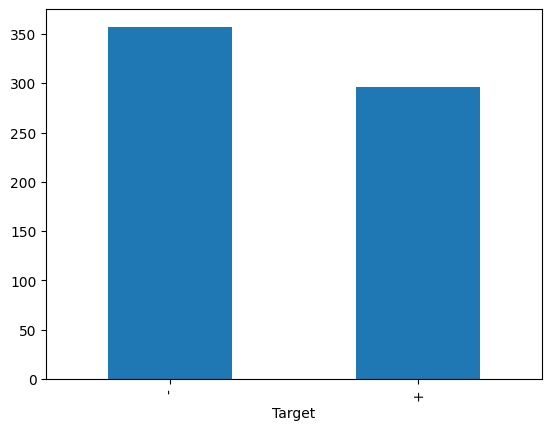

DecisionTree accuracy: 0.8396946564885496
              precision    recall  f1-score   support

           +       0.83      0.81      0.82        59
           -       0.85      0.86      0.86        72

    accuracy                           0.84       131
   macro avg       0.84      0.84      0.84       131
weighted avg       0.84      0.84      0.84       131

LogisticRegression accuracy: 0.8473282442748091
              precision    recall  f1-score   support

           +       0.83      0.83      0.83        59
           -       0.86      0.86      0.86        72

    accuracy                           0.85       131
   macro avg       0.85      0.85      0.85       131
weighted avg       0.85      0.85      0.85       131

KNN accuracy: 0.5877862595419847
              precision    recall  f1-score   support

           +       0.61      0.24      0.34        59
           -       0.58      0.88      0.70        72

    accuracy                           0.59       131
   ma

In [2]:
cols = ["A1","A2","A3","A4","A5","A6","A7","A8","A9","A10","A11","A12","A13","A14","A15","Target"]
df = pd.read_csv("data/crx.data", header=None, names=cols)
df = df.replace("?", np.nan).dropna()

df["Target"].value_counts().plot(kind="bar")
plt.show()

X = df.drop(columns=["Target"])
y = df["Target"]

X = pd.get_dummies(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("DecisionTree accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("LogisticRegression accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))